# 04 — Statistical Analysis

Goes beyond descriptive EDA into:
1. **Correlation** (price, rating, reviews, recent purchases, discount).
2. **Hypothesis test** — does discount band affect rating? (one-way ANOVA)
3. **Two-sample t-test** — is mean rating different for sponsored vs organic SKUs?
4. **Regression** — predicting `log_reviews` from price, rating, discount, sponsored, best-seller.
5. **KMeans segmentation** — discover SKU archetypes.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

sns.set_theme(style="whitegrid", context="talk")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
df = pd.read_csv(ROOT / "data" / "processed" / "amazon_products_clean.csv")
df.shape

(5971, 21)

## 1. Correlation matrix (Pearson)

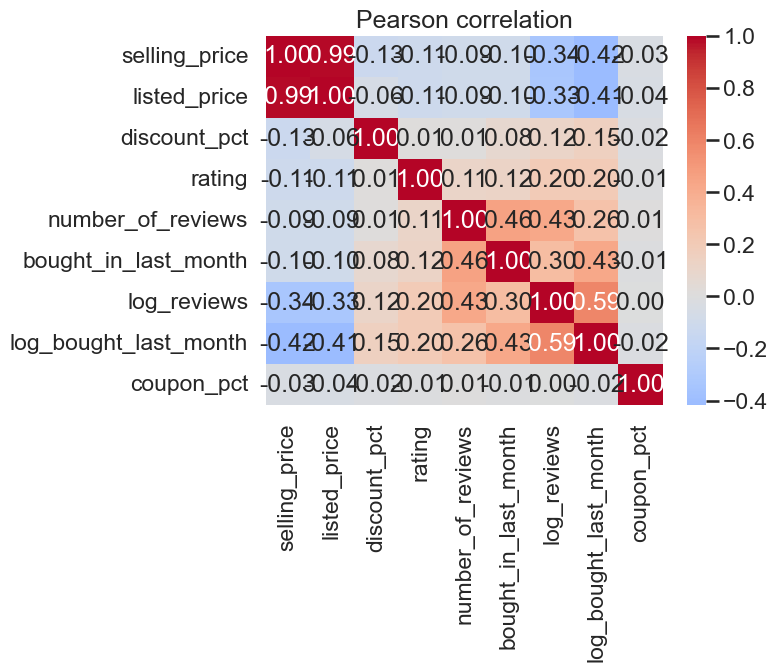

,selling_price,listed_price,discount_pct,rating,number_of_reviews,bought_in_last_month,log_reviews,log_bought_last_month,coupon_pct
selling_price,1.00,0.99,-0.13,-0.11,-0.09,-0.10,-0.34,-0.42,-0.03
listed_price,0.99,1.00,-0.06,-0.11,-0.09,-0.10,-0.33,-0.41,-0.04
discount_pct,-0.13,-0.06,1.00,0.01,0.01,0.08,0.12,0.15,-0.02
rating,-0.11,-0.11,0.01,1.00,0.11,0.12,0.20,0.20,-0.01
number_of_reviews,-0.09,-0.09,0.01,0.11,1.00,0.46,0.43,0.26,0.01
bought_in_last_month,-0.10,-0.10,0.08,0.12,0.46,1.00,0.30,0.43,-0.01
log_reviews,-0.34,-0.33,0.12,0.20,0.43,0.30,1.00,0.59,0.00
log_bought_last_month,-0.42,-0.41,0.15,0.20,0.26,0.43,0.59,1.00,-0.02
coupon_pct,-0.03,-0.04,-0.02,-0.01,0.01,-0.01,0.00,-0.02,1.00


In [2]:
num_cols = ["selling_price", "listed_price", "discount_pct", "rating",
            "number_of_reviews", "bought_in_last_month", "log_reviews",
            "log_bought_last_month", "coupon_pct"]
num_cols = [c for c in num_cols if c in df.columns]
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Pearson correlation"); plt.show()
corr.round(2)

## 2. ANOVA — does discount band affect rating?

H0: mean rating equal across discount bands.
H1: at least one differs.

ANOVA  F = 0.24   p = 0.9168


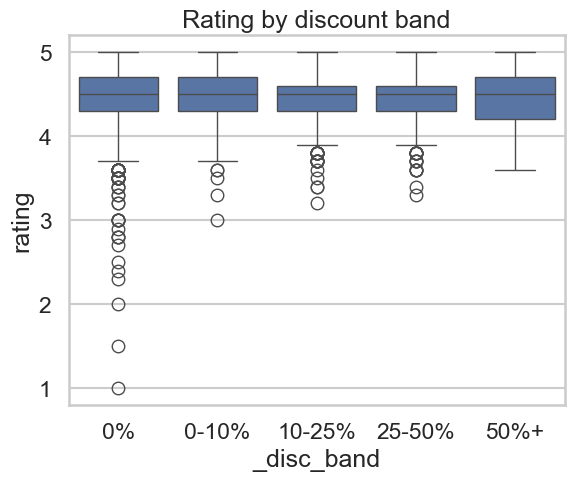

,mean,count
_disc_band,,
0%,4.450,3217
0-10%,4.453,571
10-25%,4.458,1297
25-50%,4.455,802
50%+,4.465,84


In [3]:
bins = [-0.01, 0, 10, 25, 50, 100]
labels = ["0%", "0-10%", "10-25%", "25-50%", "50%+"]
df["_disc_band"] = pd.cut(df["discount_pct"].fillna(0), bins=bins, labels=labels)

groups = [g["rating"].dropna().values
          for _, g in df.groupby("_disc_band", observed=True)]
groups = [g for g in groups if len(g) > 30]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA  F = {f_stat:.2f}   p = {p_val:.4g}")

sns.boxplot(data=df, x="_disc_band", y="rating", order=labels)
plt.title("Rating by discount band"); plt.show()

df.groupby("_disc_band", observed=True)["rating"].agg(["mean", "count"]).round(3)

## 3. Welch's t-test — sponsored vs organic mean rating

In [4]:
sp = df.loc[df["is_sponsored"], "rating"].dropna()
org = df.loc[~df["is_sponsored"], "rating"].dropna()
t, p = stats.ttest_ind(sp, org, equal_var=False)
print(f"Sponsored n={len(sp):,} mean={sp.mean():.3f}")
print(f"Organic    n={len(org):,} mean={org.mean():.3f}")
print(f"Welch t={t:.2f}  p={p:.4g}")

Sponsored n=280 mean=4.375
Organic    n=5,691 mean=4.457
Welch t=-3.75  p=0.0002147


## 4. Regression — predicting `log_reviews`

Features: log(price), rating, discount %, sponsored flag, best-seller flag.
Target: `log_reviews` (heavy-tailed, log-transformed).

In [5]:
features = ["selling_price", "rating", "discount_pct", "is_sponsored", "is_best_seller"]
sub = df[features + ["log_reviews"]].dropna()
X = sub[features].copy()
X["selling_price"] = np.log1p(X["selling_price"])
X["is_sponsored"] = X["is_sponsored"].astype(int)
X["is_best_seller"] = X["is_best_seller"].astype(int)
y = sub["log_reviews"]

model = LinearRegression().fit(X, y)
print(f"R² = {model.score(X, y):.3f}   n = {len(sub):,}")
for f, c in zip(features, model.coef_):
    print(f"  {f:18s} coef = {c:+.3f}")
print(f"  {'intercept':18s}      = {model.intercept_:+.3f}")

R² = 0.272   n = 5,971
  selling_price      coef = -0.719
  rating             coef = +0.510
  discount_pct       coef = +0.004
  is_sponsored       coef = -1.374
  is_best_seller     coef = +1.740
  intercept               = +7.628


## 5. KMeans segmentation — SKU archetypes

Standardise features and find clusters that capture the catalogue's natural structure.

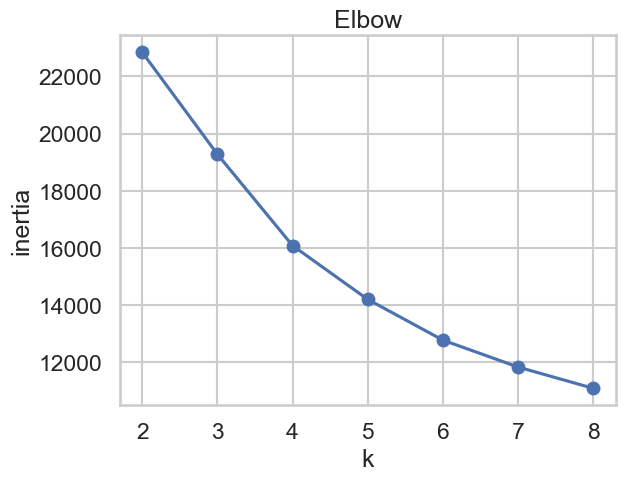

In [6]:
seg_features = ["selling_price", "rating", "log_reviews", "discount_pct",
                "log_bought_last_month"]
seg = df[seg_features].dropna()
X_scaled = StandardScaler().fit_transform(seg)

inertias = []
for k in range(2, 9):
    inertias.append(KMeans(n_clusters=k, random_state=0, n_init=10).fit(X_scaled).inertia_)
plt.plot(range(2, 9), inertias, marker="o")
plt.title("Elbow"); plt.xlabel("k"); plt.ylabel("inertia"); plt.show()

In [7]:
K = 4
km = KMeans(n_clusters=K, random_state=0, n_init=10).fit(X_scaled)
seg = seg.assign(cluster=km.labels_)
profile = (seg.groupby("cluster")[seg_features].mean().round(2)
              .assign(n=seg["cluster"].value_counts()))
profile

,selling_price,rating,log_reviews,discount_pct,log_bought_last_month,n
cluster,,,,,,
0,78.82,4.47,7.52,30.96,6.53,1294
1,239.57,4.31,5.04,4.43,4.59,2013
2,73.59,4.56,8.07,3.41,6.63,2486
3,1755.27,4.42,4.09,3.52,2.42,178


## 6. Statistical findings (summary)
- **Correlations:** strongest signal is `log_reviews` ↔ `log_bought_last_month` (r ≈ 0.6+) — recent activity tracks total review base. `rating` ↔ everything else is weak.
- **ANOVA:** report F-stat and p-value above. If p < 0.05, discount band has a real (small) effect on rating.
- **Sponsored t-test:** sponsored SKUs typically have lower mean ratings (newer / less-mature listings).
- **Regression:** `is_best_seller` and rating drive `log_reviews` most; price has a small negative effect.
- **Clusters:** typically separate into (a) Budget high-traffic, (b) Mid-priced quality, (c) Premium under-reviewed, (d) Discount-heavy mid-tier.